In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

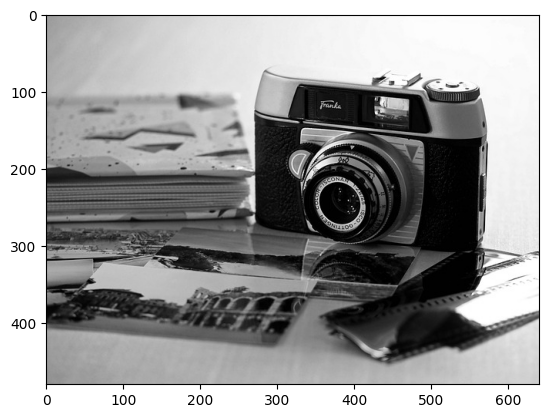

In [2]:
img = plt.imread(r'img.jpg')
plt.imshow(img,cmap='grey')

In [3]:
edge = cv2.Canny(img,350,600)


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

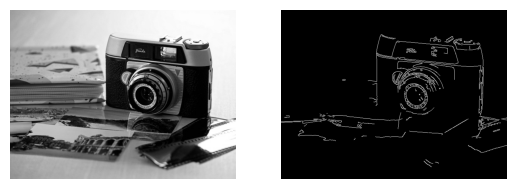

In [4]:
plt.subplot(121)
plt.imshow(img,cmap='grey')
plt.axis('off')
plt.subplot(122)
plt.imshow(edge,cmap='grey')
plt.axis('off')

In [5]:
def f_getGaussianFilter(size_of_the_filter, sigma):
    maxX = size_of_the_filter//2
    minX = -maxX
    minY = minX
    maxY = maxX
    G = np.zeros((size_of_the_filter,size_of_the_filter))
    for x in range(minX,maxX+1):
        for y in range(minY,maxY+1):
            v = (1/(2*np.pi*(sigma**2)))*np.exp(-(x**2 + y**2 )/(2*(sigma**2)))
            G[x-minX,y-minY] = v
    return G

In [6]:
G = f_getGaussianFilter(5, 1)
G

array([[0.00291502, 0.01306423, 0.02153928, 0.01306423, 0.00291502],
       [0.01306423, 0.05854983, 0.09653235, 0.05854983, 0.01306423],
       [0.02153928, 0.09653235, 0.15915494, 0.09653235, 0.02153928],
       [0.01306423, 0.05854983, 0.09653235, 0.05854983, 0.01306423],
       [0.00291502, 0.01306423, 0.02153928, 0.01306423, 0.00291502]])

In [7]:
np.sum(G)

np.float64(0.9818147610543744)

In [8]:
G = cv2.getGaussianKernel(5,1)
G = G.dot(G.T)
G

array([[0.00296902, 0.01330621, 0.02193823, 0.01330621, 0.00296902],
       [0.01330621, 0.0596343 , 0.09832033, 0.0596343 , 0.01330621],
       [0.02193823, 0.09832033, 0.16210282, 0.09832033, 0.02193823],
       [0.01330621, 0.0596343 , 0.09832033, 0.0596343 , 0.01330621],
       [0.00296902, 0.01330621, 0.02193823, 0.01330621, 0.00296902]])

In [9]:
np.sum(G)

np.float64(1.0)

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

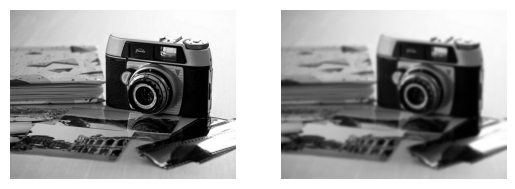

In [10]:
G = cv2.getGaussianKernel(23,3)
G = G.dot(G.T)
img_smooth = cv2.filter2D(img,-1,G)
plt.subplot(121)
plt.imshow(img,cmap='grey')
plt.axis('off')
plt.subplot(122)
plt.imshow(img_smooth,cmap='grey')
plt.axis('off')

In [11]:
img_s = img[:,:,0]
mask_x = np.zeros((2,1))
mask_x[0] = -1
mask_x[1] = 1

In [12]:
Ix = cv2.filter2D(img_s,-1,mask_x.T)

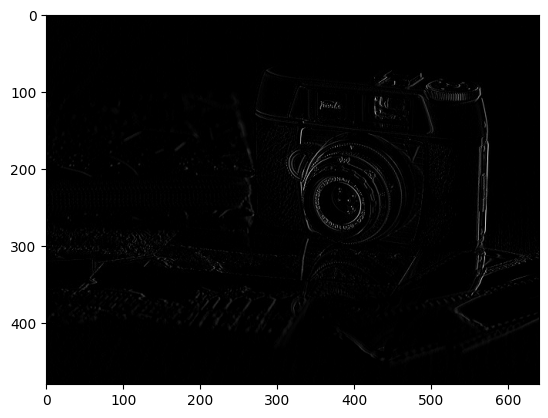

In [13]:
plt.imshow(Ix,cmap='grey')

In [14]:
def GX(size_of_the_filter, sigma):
    maxX = size_of_the_filter//2
    minX = -maxX
    minY = minX
    maxY = maxX
    Gx = np.zeros((size_of_the_filter,size_of_the_filter))
    for x in range(minX,maxX+1):
        for y in range(minY,maxY+1):
            v = (-x/(2*np.pi*(sigma**4)))*np.exp(-(x**2 + y**2 )/(2*(sigma**2)))
            Gx[x-minX,y-minY] = v
    return Gx

def GY(size_of_the_filter, sigma):
    maxX = size_of_the_filter//2
    minX = -maxX
    minY = minX
    maxY = maxX
    Gy = np.zeros((size_of_the_filter,size_of_the_filter))
    for x in range(minX,maxX+1):
        for y in range(minY,maxY+1):
            v = (-y/(2*np.pi*(sigma**4)))*np.exp(-(x**2 + y**2 )/(2*(sigma**2)))
            Gy[x-minX,y-minY] = v
    return Gy

In [15]:
gx = GX(3,0.5)
gy = GY(3,0.5)
gx

array([[ 0.04664039,  0.34462847,  0.04664039],
       [ 0.        ,  0.        ,  0.        ],
       [-0.04664039, -0.34462847, -0.04664039]])

In [16]:
gy

array([[ 0.04664039,  0.        , -0.04664039],
       [ 0.34462847,  0.        , -0.34462847],
       [ 0.04664039,  0.        , -0.04664039]])

In [17]:
img.shape

(480, 640, 3)

In [18]:
img = np.float64(img[:,:,0])

In [19]:
Ix = cv2.filter2D(img,-1,gx)
Iy = cv2.filter2D(img,-1,gy)

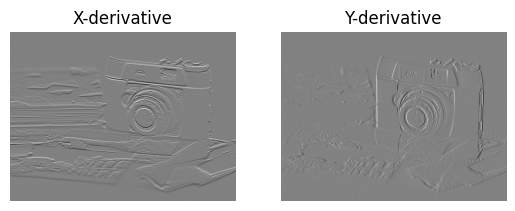

In [20]:
plt.subplot(121)
plt.imshow(Ix,cmap='grey')
plt.axis('off')
plt.title('X-derivative')
plt.subplot(122)
plt.imshow(Iy,cmap='grey')
plt.axis('off')
plt.title('Y-derivative')
plt.show()

In [21]:
Gm = np.sqrt(Ix**2 + Ix**2)
Gd = np.rad2deg(np.arctan2(Iy,Ix))

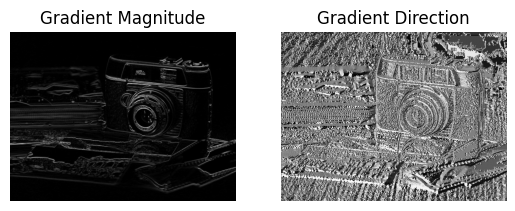

In [22]:
plt.subplot(121)
plt.imshow(Gm,cmap='grey')
plt.axis('off')
plt.title('Gradient Magnitude')
plt.subplot(122)
plt.imshow(Gd,cmap='grey')
plt.axis('off')
plt.title('Gradient Direction')
plt.show()

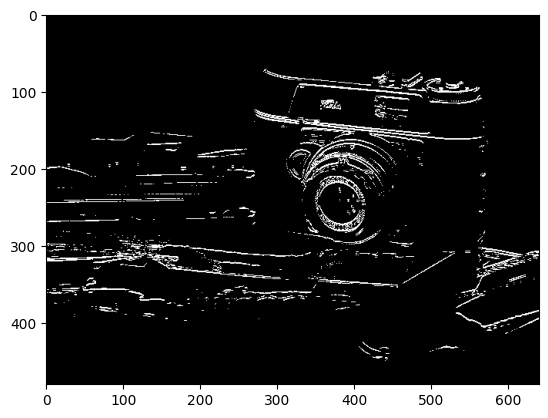

In [23]:
plt.imshow(Gm>40,cmap='grey')